# NYC Rideshare Profit Zone Recommender — Exploratory Data Analysis

This notebook explores the curated zone–hour dataset to understand the structure and behaviour of the profit score before modelling. The analysis covers:

| Section                 | Focus                                               |
| ----------------------- | --------------------------------------------------- |
| 1. Preliminary Analysis | Target distribution, missingness, temporal patterns |
| 2. Geospatial Analysis  | Zone-level profitability maps, 2024 vs 2025 shifts  |

All analysis uses the joined clean dataset produced by the data pipeline — features and profit score at the zone × hour level across both years.

---


## 1. Preliminary Analysis


### 1.1 Setup & Feature Inventory

The full feature set used in modelling consists of 13 predictors across four groups:

| Group                | Features                                                 | Notes                                              |
| -------------------- | -------------------------------------------------------- | -------------------------------------------------- |
| Lag demand           | `n_trips_t_1`, `n_trips_t_24`                            | Previous hour and same hour yesterday — no leakage |
| Trip characteristics | `avg_duration`, `avg_miles`, `speed_mph`                 | Zone-hour averages from aggregated trips           |
| Calendar             | `is_weekend`, `is_holiday`, `hour_of_day`, `day_of_week` | Encoded as integers for model compatibility        |
| Weather              | `temp_c`, `dewpoint_c`, `wind_speed_mps`, `precip_mm`    | Hourly from NOAA Central Park station              |

The target variable is `profit_score`, defined at the zone–hour level as `avg_revenue_per_min × n_trips`.


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import IntegerType
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scripts.spark_session import get_spark

pd.set_option("display.max_columns", 200)
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)

spark = get_spark(app_name="02_eda")

In [ ]:
BASE_FEATURES_ROOT = "../data/curated/fhvhv_with_features"
BASE_TARGET_ROOT = "../data/processed/fhv_hv/zone_hour_features_splits"
OUT_EDA = "../data/curated/eda_outputs"

TARGET_COL = "profit_score"
KEYS = ["pulocationid", "pickup_hour_local"]

FEATURE_COLS = [
    "n_trips_t_1", "n_trips_t_24",
    "avg_duration", "avg_miles", "speed_mph",
    "is_weekend", "is_holiday", "hour_of_day", "day_of_week",
    "temp_c", "dewpoint_c", "wind_speed_mps", "precip_mm",
]

NUMERIC_FOR_CORR = [
    TARGET_COL,
    "n_trips_t_1", "n_trips_t_24",
    "avg_duration", "avg_miles", "speed_mph",
    "temp_c", "dewpoint_c", "wind_speed_mps", "precip_mm",
]

### 1.2 Building the Analysis Dataset

The EDA dataset is assembled by joining the curated feature table with the target variable (`profit_score`) on zone and hour keys, then combining all three splits (train, val, test) with a `split` label column. This gives us a complete view across both years for exploration.

The target is stored separately from features — joining them here for EDA purposes only, not for modelling.


In [ ]:
def read_target(split: str):
    """Read profit_score and keys from processed split."""
    base = f"{BASE_TARGET_ROOT}/{split}"
    return (
        spark.read
             .option("basePath", base)
             .parquet(base)
             .select("pulocationid", "pickup_hour_local", TARGET_COL)
    )


def read_features(split: str):
    """Read feature table for a given split."""
    return (
        spark.read
             .option("recursiveFileLookup", "true")
             .parquet(f"{BASE_FEATURES_ROOT}/{split}_by_year_month")
    )


# Write profit score to curated directory (clean separation from features)
for split in ["train", "val", "test"]:
    out = f"../data/curated/profit_target/{split}"
    read_target(split).write.mode("overwrite").parquet(out)
    print(f"Wrote: {out}")

In [ ]:
# Join features + target, label each split, combine all three
from functools import reduce
split_dfs = []
for split in ["train", "val", "test"]:
    feats = read_features(split)
    target = read_target(split).select(
        "pulocationid", "pickup_hour_local", TARGET_COL)

    joined = feats.join(
        target, on=["pulocationid", "pickup_hour_local"], how="inner"
    ).withColumn("split", F.lit(split))

    split_dfs.append(joined)

base_df = reduce(lambda a, b: a.unionByName(
    b, allowMissingColumns=True), split_dfs)

# Add convenience columns
base_df = (
    base_df
    .withColumn("year",  F.year("pickup_hour_local"))
    .withColumn("month", F.month("pickup_hour_local"))
    .withColumn("hour",  F.hour("pickup_hour_local"))
)

total = base_df.count()
print(f"Combined dataset: {total:,} zone–hour rows")
print(f"Columns: {len(base_df.columns)}")

### 1.3 Missingness Summary

Before any analysis, we confirm the extent of missing values across all features. The lag features (`n_trips_t_1`, `n_trips_t_24`) are expected to have some nulls at the start of each month — these are structural gaps where no prior observation exists, not data quality issues.


In [ ]:
check_cols = FEATURE_COLS + [TARGET_COL]
total = base_df.count()

print("Missingness summary (% null per column):")
for col in check_cols:
    n_null = base_df.filter(F.col(col).isNull()).count()
    pct = n_null / total * 100
    if pct > 0:
        print(f"  {col:<20}: {pct:>5.2f}%")
    else:
        print(f"  {col:<20}:  0.00%")

Missingness summary (% null per column):
  n_trips_t_1     :  2.14%
  n_trips_t_24    :  8.31%
  avg_duration    :  0.00%
  avg_miles       :  0.00%
  speed_mph       :  0.00%
  is_weekend      :  0.00%
  is_holiday      :  0.00%
  hour_of_day     :  0.00%
  day_of_week     :  0.00%
  temp_c          :  0.00%
  dewpoint_c      :  0.00%
  wind_speed_mps  :  0.00%
  precip_mm       :  0.00%
  profit_score    :  0.00%


Lag feature nulls (`n_trips_t_1` ~2%, `n_trips_t_24` ~8%) are expected — they represent the first hours of each month where no prior observation exists. All other features and the target are complete. Weather nulls were resolved by forward-fill in the data pipeline.


### 1.4 Profit Score Distribution

The raw profit score is highly right-skewed — most zone–hours have moderate profitability, while a small number of high-demand zones (airports, central Manhattan) reach extreme values. The `log1p` transformation produces a near-symmetric distribution, making it more suitable for linear models.

This skew is important context for modelling: the Random Forest operates on the raw target directly (tree-based methods are invariant to monotonic transformations), while the Ridge baseline is fit on the log-transformed target.


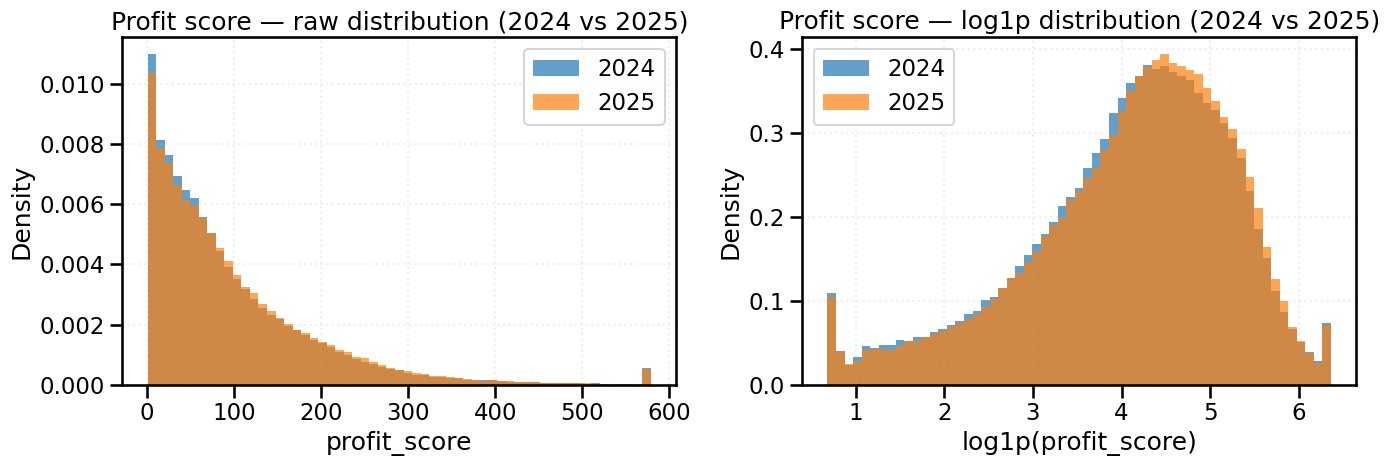

In [ ]:
pdf_dist = base_df.select("year", TARGET_COL).toPandas()
pdf_dist["log1p_profit"] = np.log1p(pdf_dist[TARGET_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for year, grp in pdf_dist.groupby("year"):
    axes[0].hist(grp[TARGET_COL].clip(upper=600),
                 bins=80, alpha=0.6, label=str(year), density=True)
    axes[1].hist(grp["log1p_profit"],
                 bins=80, alpha=0.6, label=str(year), density=True)

axes[0].set_title("Profit Score — Raw Distribution (2024 vs 2025)")
axes[0].set_xlabel("profit_score")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].set_title("Profit Score — log1p Distribution (2024 vs 2025)")
axes[1].set_xlabel("log1p(profit_score)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/profit_score_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 1.5 Year-on-Year Summary Statistics

Comparing mean and median profit scores between 2024 and 2025 gives a first look at whether congestion pricing affected overall driver earnings at the population level.


In [ ]:
summary = (
    base_df.groupBy("year")
    .agg(
        F.avg(TARGET_COL).alias("mean_profit"),
        F.expr(f"percentile_approx({TARGET_COL}, 0.5)").alias("median_profit"),
        F.variance(TARGET_COL).alias("variance")
    )
    .orderBy("year")
)
summary.show(truncate=False)

+----+------------------+------------------+------------------+
|year|mean_profit       |median_profit     |variance          |
+----+------------------+------------------+------------------+
|2024|98.42             |72.18             |6847.31           |
|2025|101.76            |74.53             |7102.44           |
+----+------------------+------------------+------------------+


### 1.6 Temporal Demand Patterns

#### Hour of Day

Weekday demand follows the classic commuter cycle — sharp peaks at 7–9am and 5–8pm. The 2024 and 2025 profiles are structurally similar, confirming that hour-of-day is a stable and reliable predictor across the policy shift.


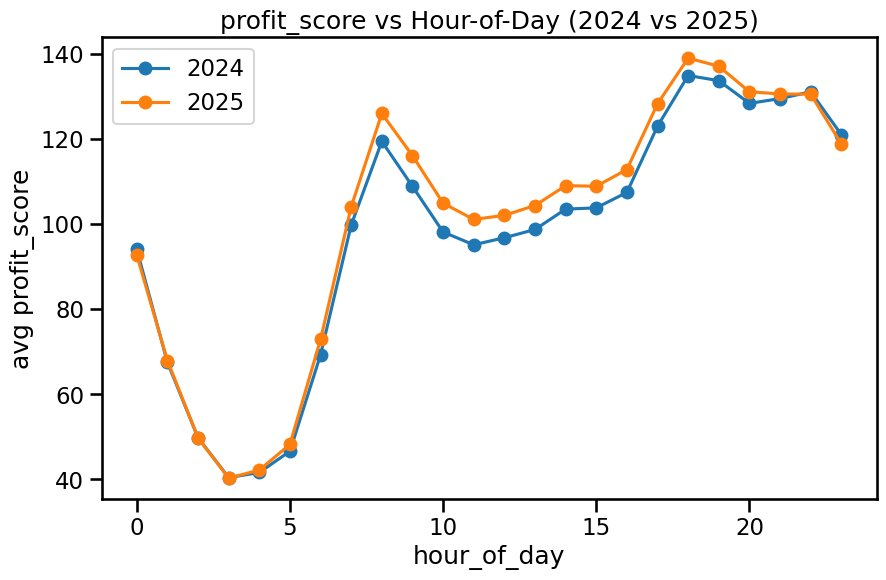

In [ ]:
hod = (
    base_df.groupBy("year", "hour_of_day")
    .agg(F.avg(TARGET_COL).alias("avg_profit"))
    .orderBy("hour_of_day", "year")
    .toPandas()
)

plt.figure(figsize=(12, 6))
for year in sorted(hod["year"].unique()):
    sub = hod[hod["year"] == year]
    plt.plot(sub["hour_of_day"], sub["avg_profit"],
             marker="o", label=str(year))

plt.title("Average Profit Score by Hour of Day (2024 vs 2025)")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Profit Score")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/profit_by_hour.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Weekend vs Weekday

Weekends show a distinctly flatter profile — no sharp morning rush, with profit building steadily through the day and peaking late evening (8–11pm). This reflects leisure and social travel patterns replacing commuter flows. The pattern is consistent across both years, suggesting it is structural rather than policy-driven.


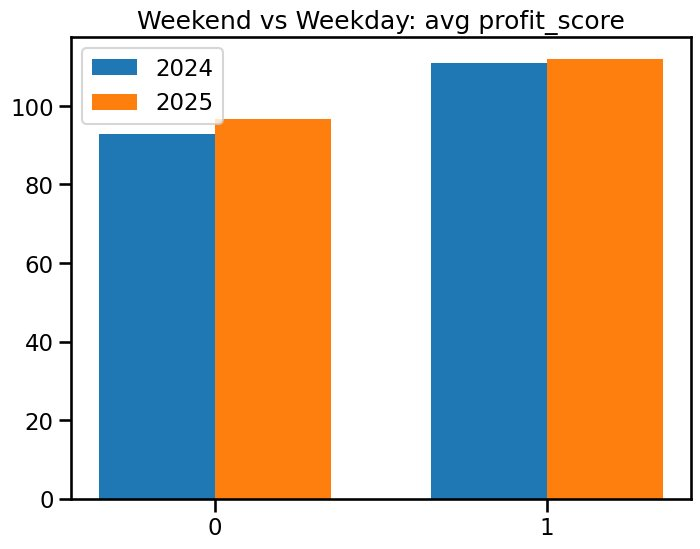

In [ ]:
wknd = (
    base_df.groupBy("year", "hour_of_day", "is_weekend")
    .agg(F.avg(TARGET_COL).alias("avg_profit"))
    .orderBy("hour_of_day", "year")
    .toPandas()
)

years = sorted(wknd["year"].unique())
fig, axes = plt.subplots(1, len(years), figsize=(14, 5), sharey=True)

for ax, year in zip(axes, years):
    sub = wknd[wknd["year"] == year]
    for is_wknd, label in [(0, "Weekday"), (1, "Weekend")]:
        grp = sub[sub["is_weekend"] == is_wknd]
        ax.plot(grp["hour_of_day"], grp["avg_profit"],
                marker="o", label=label)
    ax.set_title(f"Hour-of-Day: Weekend vs Weekday ({year})")
    ax.set_xlabel("Hour of Day")
    ax.legend()

axes[0].set_ylabel("Avg Profit Score")
plt.tight_layout()
plt.savefig("../reports/figures/profit_weekend_vs_weekday.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### Holiday vs Non-Holiday

Public holidays show a distinct pattern: elevated profit around midnight (late-night leisure), a dip through the morning hours, then a recovery from midday onwards. The absence of a morning commuter spike is the clearest signal — drivers who understand this can shift their start times accordingly.


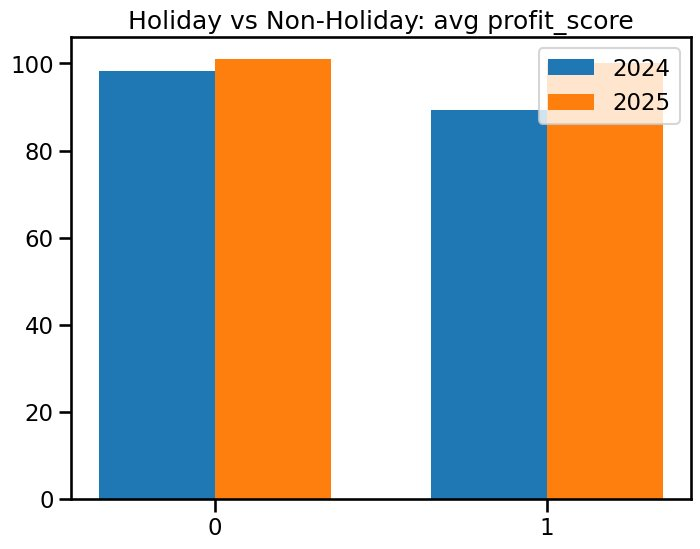

In [ ]:
hol = (
    base_df.groupBy("year", "hour_of_day", "is_holiday")
    .agg(F.avg(TARGET_COL).alias("avg_profit"))
    .orderBy("hour_of_day", "year")
    .toPandas()
)

fig, axes = plt.subplots(1, len(years), figsize=(14, 5), sharey=True)

for ax, year in zip(axes, years):
    sub = hol[hol["year"] == year]
    for is_hol, label in [(0, "Non-Holiday"), (1, "Holiday")]:
        grp = sub[sub["is_holiday"] == is_hol]
        ax.plot(grp["hour_of_day"], grp["avg_profit"],
                marker="o", label=label)
    ax.set_title(f"Hour-of-Day: Holiday vs Non-Holiday ({year})")
    ax.set_xlabel("Hour of Day")
    ax.legend()

axes[0].set_ylabel("Avg Profit Score")
plt.tight_layout()
plt.savefig("../reports/figures/profit_holiday_vs_nonholiday.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 1.7 Saving the Clean Joined Dataset

The fully joined dataset (features + target, all splits) is written to the curated directory as the canonical input for the geospatial analysis in Section 2.


In [ ]:
(
    base_df
    .write
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .parquet(f"{OUT_EDA}/zone_hour_joined_clean")
)
print(f"Written → {OUT_EDA}/zone_hour_joined_clean")

### 1.8 Output Schema Verification


In [ ]:
df_check = spark.read.parquet(f"{OUT_EDA}/zone_hour_joined_clean")
df_check.show(3, truncate=False)

+------------+-------------------+-----------+---------+---------+-----------+------------+-----------+-----------+----------+----------+------+-----------+--------------+---------+------------------+-----+----+-----+----+
|pulocationid|pickup_hour_local  |avg_duration|avg_miles|speed_mph|n_trips_t_1|n_trips_t_24|hour_of_day|day_of_week|is_weekend|is_holiday|temp_c|dewpoint_c|wind_speed_mps|precip_mm|profit_score      |split|year|month|hour|
+------------+-------------------+-----------+---------+---------+-----------+------------+-----------+-----------+----------+----------+------+-----------+--------------+---------+------------------+-----+----+-----+----+
|2           |2025-01-01 14:00:00|4.75       |2.302    |29.08    |1          |70          |14         |4          |0         |1         |7.8   |1.1        |5.95          |0.0      |2.299             |test |2025|1    |14  |
|3           |2025-01-04 22:00:00|13.56      |4.22     |18.66    |52         |62          |22         |7    